In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt

In [2]:
import numpy as np
mnist=tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [3]:
x_train=x_train/255.0
x_test=x_test/255.0

In [4]:
#Define the CNN Architeture
model=models.Sequential([
    #Layer 1:conv+relu+Maxpool
    layers.Conv2D(32,kernel_size=(3,3),activation="relu",padding="same",
                  input_shape=(28,28,1)),
    layers.MaxPooling2D(pool_size=(2,2)),
     #Layer 2:conv+relu+Maxpool
    layers.Conv2D(64,kernel_size=(3,3),activation="relu",padding="same"),
    layers.MaxPooling2D(pool_size=(2,2)),
    #classification Head
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),#Regularization to prevent overfiting
    layers.Dense(10,activation="softmax")])

C:\Users\BCA LAB 10\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
#compile the model
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=['accuracy'])
#print architechture summary
model.summary()
history=model.fit(x_train,y_train,batch_size=64,epochs=5,validation_split=0.1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9261 - loss: 0.2448 - val_accuracy: 0.9860 - val_loss: 0.0486
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9755 - loss: 0.0837 - val_accuracy: 0.9903 - val_loss: 0.0373
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9811 - loss: 0.0634 - val_accuracy: 0.9910 - val_loss: 0.0338
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9840 - loss: 0.0517 - val_accuracy: 0.9908 - val_loss: 0.0332
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9864 - loss: 0.0440 - val_accuracy: 0.9927 - val_loss: 0.0324


In [6]:
test_loss,test_acc=model.evaluate(x_test,y_test,verbose=2)
print("Test loss: ",test_loss)
print("Test Accuracy: ",test_acc)

predictions=model.predict(x_test[:11])

313/313 - 1s - 3ms/step - accuracy: 0.9917 - loss: 0.0237
Test loss:  0.023718224838376045
Test Accuracy:  0.9916999936103821
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [7]:
l=[]
for i in range(11):
    predicted_label=np.argmax(predictions[i])
    l.append(predicted_label)
    actual_tabel=y_test[i]
    print(f"Sample{i}:Predicted={ predicted_label},Actual={actual_tabel}")
#print(predicted_label)

Sample0:Predicted=7,Actual=7
Sample1:Predicted=2,Actual=2
Sample2:Predicted=1,Actual=1
Sample3:Predicted=0,Actual=0
Sample4:Predicted=4,Actual=4
Sample5:Predicted=1,Actual=1
Sample6:Predicted=4,Actual=4
Sample7:Predicted=9,Actual=9
Sample8:Predicted=5,Actual=5
Sample9:Predicted=9,Actual=9
Sample10:Predicted=0,Actual=0


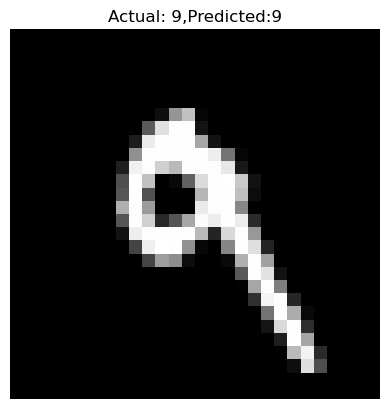

In [8]:
plt.imshow(x_test[7].squeeze(),cmap="gray")
plt.title(f"Actual: {y_test[7]},Predicted:{l[7]}")
plt.axis("off")
plt.show()